In [1]:
import pandas as pd

DATA_PATH = "../student_placement_phase1_ready.xlsx"

df = pd.read_excel(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (100000, 20)


,college_pursuing_year,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,hackathons_participated,github_repos,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,placement_status
0,4,7.53,IT,Tier 2,4,6,1,99.238568,81.707722,57.707166,59.070073,4,1,72.647009,77.463863,2,63.382726,52.938240,Yes,Not Placed
1,4,7.92,CSE,Tier 2,1,3,6,80.966123,63.116715,59.197085,78.976419,0,2,61.699110,88.887600,1,73.694605,60.198856,No,Not Placed
2,4,8.60,EEE,Tier 1,0,1,1,49.177184,48.658753,92.104885,80.603331,0,2,87.396911,74.153265,0,63.329294,43.708803,No,Placed
3,4,6.68,CSE,Tier 1,0,2,2,79.359084,66.376653,83.411798,64.187246,1,1,58.401069,87.635955,1,47.636099,56.549154,Yes,Not Placed
4,3,8.43,IT,Tier 3,1,4,3,65.018573,61.274985,88.956331,56.163678,1,4,74.489201,79.120749,1,0.000000,67.268893,No,Placed


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)

In [3]:
print(df.shape)
print(df.columns.tolist())

(100000, 20)
['college_pursuing_year', 'cgpa', 'branch', 'college_tier', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'volunteer_experience', 'placement_status']


In [4]:
# Define the same 19 features used in Phase 1

features = [
    "college_pursuing_year",
    "cgpa",
    "branch",
    "college_tier",
    "internships_count",
    "projects_count",
    "certifications_count",
    "coding_skill_score",
    "aptitude_score",
    "communication_skill_score",
    "logical_reasoning_score",
    "hackathons_participated",
    "github_repos",
    "mock_interview_score",
    "attendance_percentage",
    "backlogs",
    "extracurricular_score",
    "leadership_score",
    "volunteer_experience"
]

X = df[features]
y = df["placement_status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100000, 19)
y shape: (100000,)


In [5]:
y = y.map({
    "Not Placed": 0,
    "Placed": 1
})

print(y.value_counts())

placement_status
1    54459
0    45541
Name: count, dtype: int64


In [6]:
X = pd.get_dummies(
    X,
    columns=[
        "branch",
        "college_tier",
        "volunteer_experience"
    ],
    drop_first=True
)

X = X.astype(float)

print("Processed X shape:", X.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Processed X shape: (100000, 24)

Feature columns:
['college_pursuing_year', 'cgpa', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'branch_Civil', 'branch_ECE', 'branch_EEE', 'branch_IT', 'branch_Mechanical', 'college_tier_Tier 2', 'college_tier_Tier 3', 'volunteer_experience_Yes']


In [7]:
X_columns = X.columns.tolist()

print("Number of processed features:", len(X_columns))

Number of processed features: 24


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (80000, 24)
Testing data : (20000, 24)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Features scaled successfully.")

Features scaled successfully.


In [10]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [11]:
y_pred = logistic_model.predict(X_test)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 0 1 1 1 1 0 0 1 0 1 1 1 1 1 1 1 1 0 1]


In [12]:
y_probability = logistic_model.predict_proba(X_test)[:, 1]

print("First 20 placement probabilities:")
print(y_probability[:20])

First 20 placement probabilities:
[0.37453221 0.49303099 0.53412604 0.64932799 0.70975687 0.50150387
 0.47202807 0.46215152 0.63174908 0.49279906 0.58018968 0.58698974
 0.70765801 0.65623112 0.67288922 0.52007018 0.57343284 0.55680296
 0.35097091 0.6126951 ]


In [13]:
placement_probability = y_probability * 100

print("First 20 placement probabilities (%):")
print(placement_probability[:20])

First 20 placement probabilities (%):
[37.45322125 49.30309905 53.41260446 64.93279942 70.9756872  50.15038712
 47.20280667 46.21515237 63.17490803 49.27990577 58.01896763 58.69897449
 70.76580092 65.62311238 67.28892237 52.00701792 57.34328391 55.68029634
 35.09709111 61.26951003]


In [14]:
prediction_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Placement_Probability": placement_probability
})

prediction_results.head(20)

,Actual,Predicted,Placement_Probability
0,0,0,37.453221
1,1,0,49.303099
2,1,1,53.412604
3,1,1,64.932799
4,1,1,70.975687
5,1,1,50.150387
6,1,0,47.202807
7,1,0,46.215152
8,1,1,63.174908
9,0,0,49.279906


In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability)

print("Logistic Regression Results")
print("=" * 40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Logistic Regression Results
Accuracy : 0.5670
Precision: 0.5762
Recall   : 0.7694
F1 Score : 0.6589
ROC-AUC  : 0.5850


In [16]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Placed", "Placed"]
    )
)

              precision    recall  f1-score   support

  Not Placed       0.54      0.33      0.41      9127
      Placed       0.58      0.77      0.66     10873

    accuracy                           0.57     20000
   macro avg       0.56      0.55      0.53     20000
weighted avg       0.56      0.57      0.54     20000



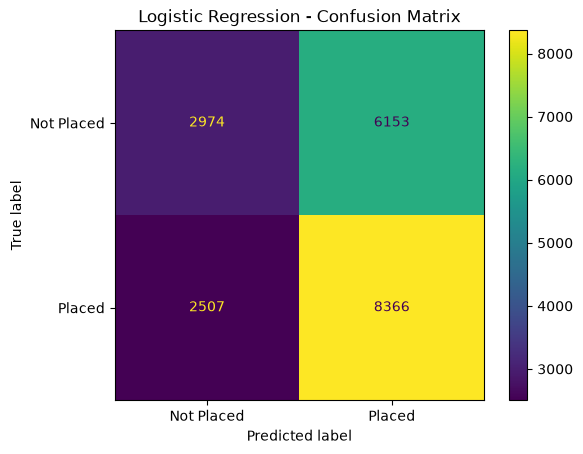

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Placed", "Placed"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

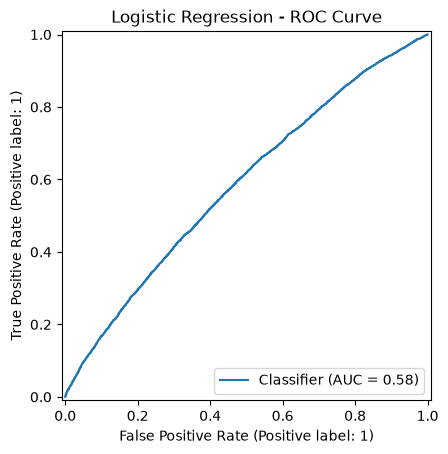

In [18]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(
    y_test,
    y_probability
)

plt.title("Logistic Regression - ROC Curve")
plt.show()

In [19]:
import numpy as np
import pandas as pd

coefficients = logistic_model.coef_[0]

logistic_weights = pd.DataFrame({
    "Feature": X_columns,
    "Coefficient": coefficients
})

logistic_weights["Absolute_Coefficient"] = (
    logistic_weights["Coefficient"].abs()
)

logistic_weights["Odds_Ratio"] = np.exp(
    logistic_weights["Coefficient"]
)

logistic_weights = logistic_weights.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

logistic_weights.head(20)

,Feature,Coefficient,Absolute_Coefficient,Odds_Ratio
13,backlogs,-0.172108,0.172108,0.841888
2,internships_count,0.133105,0.133105,1.142370
3,projects_count,0.127890,0.127890,1.136428
5,coding_skill_score,0.106102,0.106102,1.111935
11,mock_interview_score,0.091159,0.091159,1.095443
7,communication_skill_score,0.070718,0.070718,1.073279
8,logical_reasoning_score,0.067668,0.067668,1.070010
6,aptitude_score,0.064991,0.064991,1.067150
15,leadership_score,0.046030,0.046030,1.047106
14,extracurricular_score,0.040498,0.040498,1.041329


In [20]:
import pandas as pd

evaluation_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

evaluation_results

,Metric,Score
0,Accuracy,0.567000
1,Precision,0.576210
2,Recall,0.769429
3,F1 Score,0.658948
4,ROC-AUC,0.584990


In [21]:
results = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1_score", "roc_auc"],
    "value": [accuracy, precision, recall, f1, roc_auc],
})

results.to_csv("logistic_regression_results.csv", index=False)
print("Saved logistic_regression_results.csv")

Saved logistic_regression_results.csv
